In [37]:
#%pip install lightgbm xgboost catboost


In [38]:
import torch


print('✅ PyTorch GPU dispo:', torch.cuda.is_available())

✅ PyTorch GPU dispo: True


In [39]:
import os
import pandas as pd
import joblib
from datetime import datetime

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from src.simulator_betting import *
from src.simulator_grid import *
from src.config import *
from src.utils import get_latest_file

import json

pd.set_option("display.max_columns", None)

from src.simulator_grid import run_parallel_simulations

In [40]:
bets_df, summary = run_season_simulation(
            seasons_to_test=["2021-22","2022-23","2023-24"], #, "2023-24"],
            exclude_future_seasons=True,
            min_ev=0.1,
            odds_max=2.4,
            odds_min=1.2,
            prob_diff=0.00001,
            ev_diff_min=0.00001,
            bankroll=1000,
            max_risk=0.1,
            stake_method="fixed",
            streak_limit=55,
            bankroll_stop=0,
            skip_first_n=0,
            model_identifier="odds_newdocker",
            reset_bankroll_each_season=False,
            parallel = True
        )


#save the bets DataFrame to a CSV file

os.makedirs(DATA_SIMULATIONS_DIR, exist_ok=True)
today = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M-%S")
bets_output_file = os.path.join(DATA_SIMULATIONS_DIR, f"bets_{today}.csv")

bets_df.to_csv(bets_output_file, index=False)



--- Saison: 2021-22 ---
Model in parallel mode: True. n_jobs set to -1
Chargement du modèle existant pour 2021-22 (odds_newdocker)
Modèle chargé depuis data\models\simulations\model_2021-22_odds_newdocker.joblib
dataset cols before SIM : ['GAME_ID', 'TEAM_ID', 'GAME_DATE', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TO', 'PF', 'PTS', 'PLUS_MINUS', 'MINUTES_PLAYED', 'OPP_TEAM_ID', 'OPP_GAME_DATE', 'OPP_FGM', 'OPP_FGA', 'OPP_FG_PCT', 'OPP_FG3M', 'OPP_FG3A', 'OPP_FG3_PCT', 'OPP_FTM', 'OPP_FTA', 'OPP_FT_PCT', 'OPP_OREB', 'OPP_DREB', 'OPP_REB', 'OPP_AST', 'OPP_STL', 'OPP_BLK', 'OPP_TO', 'OPP_PF', 'OPP_PTS', 'OPP_PLUS_MINUS', 'OPP_MINUTES_PLAYED', 'MATCHUP', 'SEASON', 'IS_HOME', 'IS_WIN', 'POINT_DIFF', 'TEAM_NAME', 'OPPONENT_NAME', 'ODDS', 'OPP_ODDS', 'TS_PCT', 'EFG_PCT', 'AST_TO_RATIO', 'REB_RATE', 'POSSESSIONS', 'OPP_POSSESSIONS', 'OFF_RATING', 'DEF_RATING', 'ROLL_PTS_3', 'ROLL_PTS_5', 'ROLL_PTS_10', 'ROLL_PTS_25'

In [41]:
print("Summary of bets :")
print(summary)

Summary of bets :
{'total_analysed': 3949, 'total_bet_placed': 16, 'wins': np.int64(9), 'roi': np.float64(0.04297748044536769), 'final_bankroll': np.float64(1072.0161974934513)}


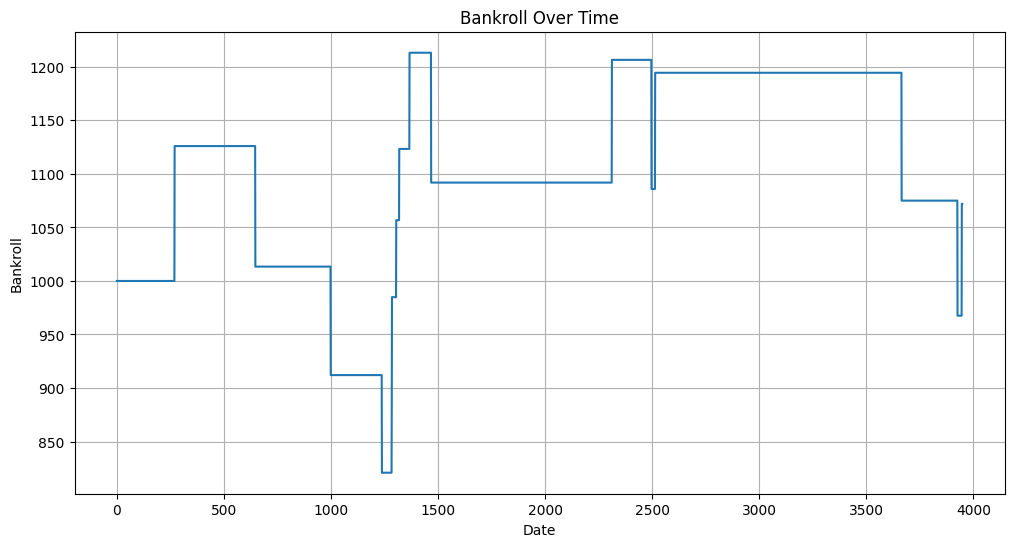

In [42]:
#plot bets_df

import matplotlib.pyplot as plt
bets_df['bankroll'].plot(kind='line', figsize=(12, 6), title='Bankroll Over Time')
plt.xlabel('Date')
plt.ylabel('Bankroll')
plt.grid()





In [43]:
# results = run_parallel_simulations(
#     seasons=["2022-23"], #, "2023-24"],
#     model_identifier="grid_odds",
#     reset_bankroll_each_season=False
# )


In [44]:
#latest simulation file
latest_simulation_file = get_latest_file(DATA_SIMULATIONS_DIR)
print(f"Latest simulation file: {latest_simulation_file}")


#analyse edge bookmaker/models on the latest simulation file
latest_bets_df = pd.read_csv(latest_simulation_file)
analyze_model_vs_bookmaker(latest_bets_df)


Latest simulation file: data\simulations\bets_2025-06-02_14-44-03.csv


e:\Documents_\Dev\NBA_Predictor\src\simulator_betting.py:391: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis = df.groupby("diff_bin").agg(


,diff_bin,gain_mean,gain_total,won_mean,stake_mean,count
0,"(-1.0, -0.25]",0.000000,0.000000,0.161417,0.000000,0
1,"(-0.25, -0.15]",0.000000,0.000000,0.258696,0.000000,0
2,"(-0.15, -0.05]",0.000000,0.000000,0.358261,0.000000,0
3,"(-0.05, 0.05]",-0.990934,-648.071062,0.509174,1.336500,8
4,"(0.05, 0.15]",0.790219,653.510889,0.605804,0.841505,7
5,"(0.15, 0.25]",0.113612,66.576371,0.675768,0.180336,1
6,"(0.25, 1.0]",0.000000,0.000000,0.784661,0.000000,0


In [45]:


# Trouver le dernier fichier de résumé
# summary_files = sorted([f for f in os.listdir(DATA_GRID_SIMULATIONS_BETS_DIR) if f.startswith("summary_grid_results")])
# latest_summary_path = os.path.join(DATA_GRID_SIMULATIONS_BETS_DIR, summary_files[-1])

# with open(latest_summary_path, 'r') as f:
#     grid_results = json.load(f)

# # Afficher les meilleurs runs par exemple par bankroll finale
# sorted_results = sorted(
#     [res for res in grid_results if "final_bankroll" in res],
#     key=lambda x: x["final_bankroll"],
#     reverse=True
# )

# for r in sorted_results[:10]:
#     print(f"{r['param_suffix']} - Final bankroll: {r['final_bankroll']:.2f}, ROI: {r['roi']:.3f}, Wins: {r['wins']}/{r['total_bets']}")
